# 🖼️ AI-Generated Image Detection

Detecting whether an image was photographed from real life or generated by an AI model (Stable Diffusion).

### Models
| Model | Type |
|-------|------|
| ResNet-18 | CNN baseline (fine-tuned) |
| ViT-B/16 | Vision Transformer (fine-tuned) |
| CLIP | Zero-shot (no training) |

### Dataset
[CIFAKE](https://www.kaggle.com/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images) — 60K real (CIFAR-10) + 60K AI-generated (Stable Diffusion)

### Setup
- Enable GPU: Runtime → Change runtime type → T4 GPU
- Upload `cifake.zip` before running (already uploaded to `/content/`)

In [ ]:
# ── Install dependencies ──────────────────────────────────────────────────────
!pip install torch torchvision transformers scikit-learn matplotlib seaborn --quiet

In [ ]:
# ── Imports ───────────────────────────────────────────────────────────────────
import os
import zipfile
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from transformers import ViTForImageClassification, AutoFeatureExtractor
from transformers import CLIPProcessor, CLIPModel

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print('All imports successful ')

---
## 1. Extract Dataset

In [24]:
# ── Extract cifake.zip ────────────────────────────────────────────────────────
ZIP_PATH    = '/content/cifake.zip'
EXTRACT_DIR = '/content/cifake/cifake'

if not os.path.exists(EXTRACT_DIR):
    print('Extracting cifake.zip...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)
    print('Extracted ')
else:
    print('Already extracted ')

# Verify structure
TRAIN_DIR = os.path.join(EXTRACT_DIR, 'train')
TEST_DIR  = os.path.join(EXTRACT_DIR, 'test')

# Handle nested zip structure if needed
if not os.path.exists(TRAIN_DIR):
    # Try one level deeper
    subdirs = os.listdir(EXTRACT_DIR)
    if len(subdirs) == 1:
        EXTRACT_DIR = os.path.join(EXTRACT_DIR, subdirs[0])
        TRAIN_DIR   = os.path.join(EXTRACT_DIR, 'train')
        TEST_DIR    = os.path.join(EXTRACT_DIR, 'test')

for split, path in [('train', TRAIN_DIR), ('test', TEST_DIR)]:
    real = len(os.listdir(os.path.join(path, 'REAL')))
    fake = len(os.listdir(os.path.join(path, 'FAKE')))
    print(f'{split}: REAL={real:,} | FAKE={fake:,} | Total={real+fake:,}')

Already extracted 
train: REAL=50,000 | FAKE=50,000 | Total=100,000
test: REAL=10,000 | FAKE=10,000 | Total=20,000


---
## 2. Exploratory Data Analysis

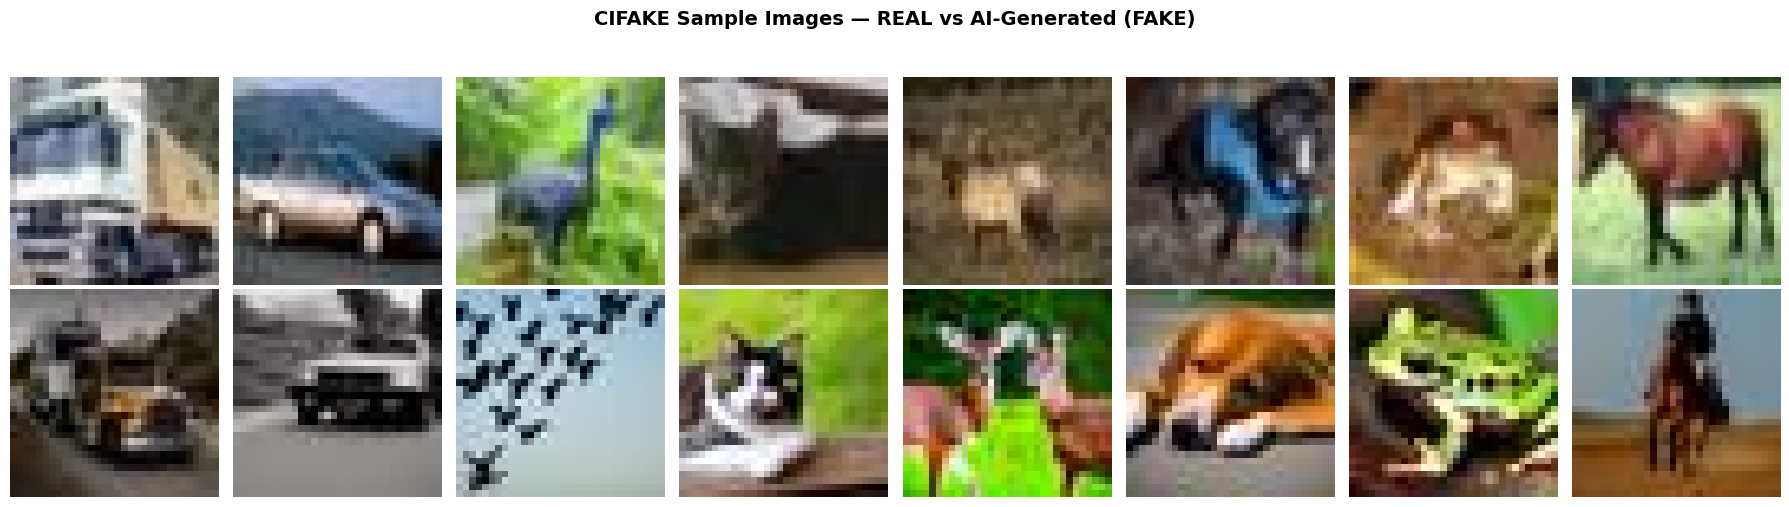

In [8]:
# ── Visualize sample images ───────────────────────────────────────────────────
from PIL import Image

fig, axes = plt.subplots(2, 8, figsize=(18, 5))

for row, label in enumerate(['REAL', 'FAKE']):
    folder = os.path.join(TRAIN_DIR, label)
    images = sorted(os.listdir(folder))[:8]
    for col, img_name in enumerate(images):
        img = Image.open(os.path.join(folder, img_name))
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(label, fontsize=12, fontweight='bold')

plt.suptitle('CIFAKE Sample Images — REAL vs AI-Generated (FAKE)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

Computing pixel statistics...


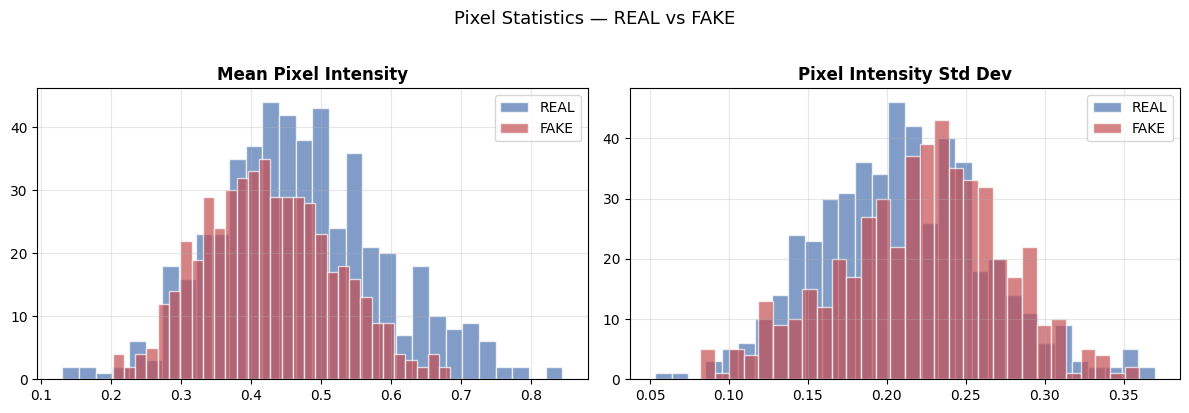

REAL — Mean: 0.470 | Std: 0.210
FAKE — Mean: 0.425 | Std: 0.222


In [9]:
# ── Pixel statistics: real vs fake ───────────────────────────────────────────
print('Computing pixel statistics...')

def sample_pixel_stats(folder, n=500):
    files = sorted(os.listdir(folder))[:n]
    means, stds = [], []
    for f in files:
        img = np.array(Image.open(os.path.join(folder, f)).convert('RGB')) / 255.0
        means.append(img.mean())
        stds.append(img.std())
    return np.array(means), np.array(stds)

real_means, real_stds = sample_pixel_stats(os.path.join(TRAIN_DIR, 'REAL'))
fake_means, fake_stds = sample_pixel_stats(os.path.join(TRAIN_DIR, 'FAKE'))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(real_means, bins=30, alpha=0.7, color='#4C72B0', label='REAL', edgecolor='white')
axes[0].hist(fake_means, bins=30, alpha=0.7, color='#C44E52', label='FAKE', edgecolor='white')
axes[0].set_title('Mean Pixel Intensity', fontsize=12, fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].hist(real_stds, bins=30, alpha=0.7, color='#4C72B0', label='REAL', edgecolor='white')
axes[1].hist(fake_stds, bins=30, alpha=0.7, color='#C44E52', label='FAKE', edgecolor='white')
axes[1].set_title('Pixel Intensity Std Dev', fontsize=12, fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Pixel Statistics — REAL vs FAKE', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('pixel_stats.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'REAL — Mean: {real_means.mean():.3f} | Std: {real_stds.mean():.3f}')
print(f'FAKE — Mean: {fake_means.mean():.3f} | Std: {fake_stds.mean():.3f}')

---
## 3. Data Loaders

In [10]:
# ── Transforms ────────────────────────────────────────────────────────────────
IMG_SIZE   = 224
BATCH_SIZE = 64

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Class mapping: ImageFolder sorts alphabetically — FAKE=0, REAL=1
CLASS_NAMES = train_dataset.classes
print(f'Classes: {CLASS_NAMES}')  # ['FAKE', 'REAL']
print(f'Train: {len(train_dataset):,} | Test: {len(test_dataset):,}')
print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

Classes: ['FAKE', 'REAL']
Train: 100,000 | Test: 20,000
Train batches: 1563 | Test batches: 313


---
## 4. Model 1: ResNet-18 (CNN Baseline)

In [11]:
# ── Training helper ───────────────────────────────────────────────────────────
def train_model(model, train_loader, test_loader, epochs=10, lr=1e-4, patience=3):
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    best_acc, patience_ctr, best_state = 0, 0, None
    train_losses, val_accs = [], []
    start = time.time()

    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        train_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_losses.append(train_loss / len(train_loader))
        scheduler.step()

        # Evaluate
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                preds = model(xb.to(device)).argmax(dim=1)
                correct += (preds == yb.to(device)).sum().item()
                total   += len(yb)
        acc = correct / total
        val_accs.append(acc)

        print(f'  Epoch {epoch:2d} | Loss: {train_losses[-1]:.4f} | Acc: {acc*100:.2f}%')

        if acc > best_acc:
            best_acc = acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
        if patience_ctr >= patience:
            print(f'  Early stopping at epoch {epoch}')
            break

    model.load_state_dict(best_state)
    print(f'Done in {time.time()-start:.1f}s | Best acc: {best_acc*100:.2f}%')
    return model, train_losses, val_accs

print('Training helper ready ✅')

Training helper ready ✅


In [ ]:
# ── Evaluation helper ─────────────────────────────────────────────────────────
def evaluate_model(model, test_loader, model_name):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for xb, yb in test_loader:
            logits = model(xb.to(device))
            probs  = torch.softmax(logits, dim=1).cpu().numpy()
            preds  = np.argmax(probs, axis=1)
            all_preds.extend(preds)
            all_labels.extend(yb.numpy())
            all_probs.extend(probs[:, 1])  # prob of REAL class

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    acc     = (all_preds == all_labels).mean()
    auc     = roc_auc_score(all_labels, all_probs)
    report  = classification_report(all_labels, all_preds,
                                     target_names=CLASS_NAMES, output_dict=True)
    f1      = report['macro avg']['f1-score']

    print(f'\n{"="*55}')
    print(f'  {model_name}')
    print(f'{"="*55}')
    print(f'  Accuracy  : {acc*100:.2f}%')
    print(f'  AUC-ROC   : {auc:.4f}')
    print(f'  Macro F1  : {f1:.4f}')
    print(f'\n{classification_report(all_labels, all_preds, target_names=CLASS_NAMES)}')

    return {
        'model': model_name, 'accuracy': acc, 'auc': auc, 'f1': f1,
        'preds': all_preds, 'labels': all_labels, 'probs': all_probs
    }

print('Evaluation helper ready ')

In [13]:
# ── Build ResNet-18 ───────────────────────────────────────────────────────────
print('Building ResNet-18...')
resnet = models.resnet18(weights='IMAGENET1K_V1')

# Freeze early layers, fine-tune last 2 blocks + classifier
for name, param in resnet.named_parameters():
    if 'layer3' not in name and 'layer4' not in name and 'fc' not in name:
        param.requires_grad = False

# Replace classifier head
resnet.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(resnet.fc.in_features, 2)
)
resnet = resnet.to(device)

trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable:,}')

print('\nTraining ResNet-18...')
resnet, resnet_losses, resnet_accs = train_model(
    resnet, train_loader, test_loader, epochs=10, lr=1e-4
)

Building ResNet-18...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 185MB/s]


Trainable parameters: 10,494,466

Training ResNet-18...
  Epoch  1 | Loss: 0.1472 | Acc: 96.74%
  Epoch  2 | Loss: 0.0913 | Acc: 95.73%
  Epoch  3 | Loss: 0.0714 | Acc: 97.23%
  Epoch  4 | Loss: 0.0564 | Acc: 97.50%
  Epoch  5 | Loss: 0.0453 | Acc: 97.75%
  Epoch  6 | Loss: 0.0323 | Acc: 97.47%
  Epoch  7 | Loss: 0.0235 | Acc: 98.05%
  Epoch  8 | Loss: 0.0170 | Acc: 98.17%
  Epoch  9 | Loss: 0.0120 | Acc: 98.38%
  Epoch 10 | Loss: 0.0098 | Acc: 98.42%
Done in 4182.2s | Best acc: 98.42%


In [ ]:
# ── Evaluate ResNet-18 ────────────────────────────────────────────────────────
resnet_results = evaluate_model(resnet, test_loader, 'ResNet-18 (CNN Baseline)')

---
## 5. Model 2: Vision Transformer (ViT-B/16)

In [ ]:
# ── Build ViT ─────────────────────────────────────────────────────────────────
print('Loading ViT-B/16...')
from transformers import ViTForImageClassification

vit = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    num_labels=2,
    ignore_mismatched_sizes=True
)

# Freeze all except last 4 transformer blocks + classifier
for name, param in vit.named_parameters():
    param.requires_grad = False

for name, param in vit.named_parameters():
    if any(f'encoder.layer.{i}' in name for i in [8, 9, 10, 11]):
        param.requires_grad = True
    if 'classifier' in name or 'layernorm' in name:
        param.requires_grad = True

vit = vit.to(device)
trainable = sum(p.numel() for p in vit.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable:,}')

# ViT wrapper for consistent interface with train_model
class ViTWrapper(nn.Module):
    def __init__(self, vit_model):
        super().__init__()
        self.vit = vit_model
    def forward(self, x):
        return self.vit(x).logits

vit_wrapper = ViTWrapper(vit).to(device)

print('\nTraining ViT-B/16...')
vit_wrapper, vit_losses, vit_accs = train_model(
    vit_wrapper, train_loader, test_loader, epochs=10, lr=2e-5
)

Loading ViT-B/16...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Trainable parameters: 28,379,138

Training ViT-B/16...
  Epoch  1 | Loss: 0.1888 | Acc: 93.84%


In [ ]:
# ── Evaluate ViT ──────────────────────────────────────────────────────────────
vit_results = evaluate_model(vit_wrapper, test_loader, 'ViT-B/16 (Vision Transformer)')

---
## 6. Model 3: CLIP Zero-Shot (No Training)

In [ ]:
# ── CLIP zero-shot ────────────────────────────────────────────────────────────
print('Loading CLIP...')
clip_model     = CLIPModel.from_pretrained('openai/clip-vit-base-patch32').to(device)
clip_processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')
clip_model.eval()

# Prompt engineering — try multiple prompt pairs
PROMPT_PAIRS = [
    ("a real photograph",           "an AI-generated image"),
    ("a photo taken by a camera",   "an image generated by artificial intelligence"),
    ("a genuine photo",             "a synthetic AI-generated picture"),
]

print(f'\nEvaluating {len(PROMPT_PAIRS)} prompt pairs...')

from PIL import Image as PILImage

def evaluate_clip(prompt_real, prompt_fake, n_batches=None):
    all_preds, all_labels, all_probs = [], [], []
    batches = 0

    for imgs, labels in test_loader:
        # Convert tensor batch back to PIL for CLIP processor
        pil_imgs = []
        for img_t in imgs:
            # Denormalize
            mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
            std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
            img_denorm = (img_t * std + mean).clamp(0, 1)
            pil_imgs.append(transforms.ToPILImage()(img_denorm))

        inputs = clip_processor(
            text=[prompt_real, prompt_fake],
            images=pil_imgs,
            return_tensors='pt',
            padding=True
        ).to(device)

        with torch.no_grad():
            outputs = clip_model(**inputs)
            # logits_per_image: (batch, 2) — similarity to [real_prompt, fake_prompt]
            logits  = outputs.logits_per_image
            probs   = torch.softmax(logits, dim=1).cpu().numpy()

        # REAL class = index 0 (first prompt), FAKE = index 1
        # But ImageFolder: FAKE=0, REAL=1 — so map accordingly
        # prob_real = probs[:, 0], pred = 1 (REAL) if prob_real > 0.5 else 0 (FAKE)
        preds = (probs[:, 0] > 0.5).astype(int)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs[:, 0])

        batches += 1
        if n_batches and batches >= n_batches:
            break

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)
    acc = (all_preds == all_labels).mean()
    auc = roc_auc_score(all_labels, all_probs)
    f1  = classification_report(all_labels, all_preds, output_dict=True)['macro avg']['f1-score']
    return acc, auc, f1, all_preds, all_labels, all_probs

# Evaluate all prompt pairs
clip_prompt_results = []
for real_p, fake_p in PROMPT_PAIRS:
    acc, auc, f1, preds, labels, probs = evaluate_clip(real_p, fake_p)
    clip_prompt_results.append({'prompts': (real_p, fake_p), 'acc': acc, 'auc': auc, 'f1': f1,
                                 'preds': preds, 'labels': labels, 'probs': probs})
    print(f'  Prompts: ["{real_p}" vs "{fake_p}"]')
    print(f'  Accuracy: {acc*100:.2f}% | AUC: {auc:.4f} | F1: {f1:.4f}\n')

# Best prompt pair
best_clip = max(clip_prompt_results, key=lambda x: x['auc'])
print(f'Best CLIP prompts: {best_clip["prompts"]}')
clip_results = {
    'model': 'CLIP Zero-Shot',
    'accuracy': best_clip['acc'],
    'auc': best_clip['auc'],
    'f1': best_clip['f1'],
    'preds': best_clip['preds'],
    'labels': best_clip['labels'],
    'probs': best_clip['probs']
}

Loading CLIP...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]


Evaluating 3 prompt pairs...
  Prompts: ["a real photograph" vs "an AI-generated image"]
  Accuracy: 52.38% | AUC: 0.6636 | F1: 0.3934

  Prompts: ["a photo taken by a camera" vs "an image generated by artificial intelligence"]
  Accuracy: 49.88% | AUC: 0.5818 | F1: 0.3350



---
## 7. Model Comparison & Visualizations

In [18]:
# ── Summary table ─────────────────────────────────────────────────────────────
import pandas as pd

all_results = [resnet_results, clip_results]
summary_df  = pd.DataFrame([{
    'Model':    r['model'],
    'Accuracy': f"{r['accuracy']*100:.2f}%",
    'AUC-ROC':  f"{r['auc']:.4f}",
    'Macro F1': f"{r['f1']:.4f}"
} for r in all_results])

print('\n' + '='*60)
print('  MODEL COMPARISON — AI-Generated Image Detection')
print('='*60)
print(summary_df.to_string(index=False))
print('='*60)


  MODEL COMPARISON — AI-Generated Image Detection
                   Model Accuracy AUC-ROC Macro F1
ResNet-18 (CNN Baseline)   98.42%  0.9986   0.9842
          CLIP Zero-Shot   55.49%  0.6826   0.4582


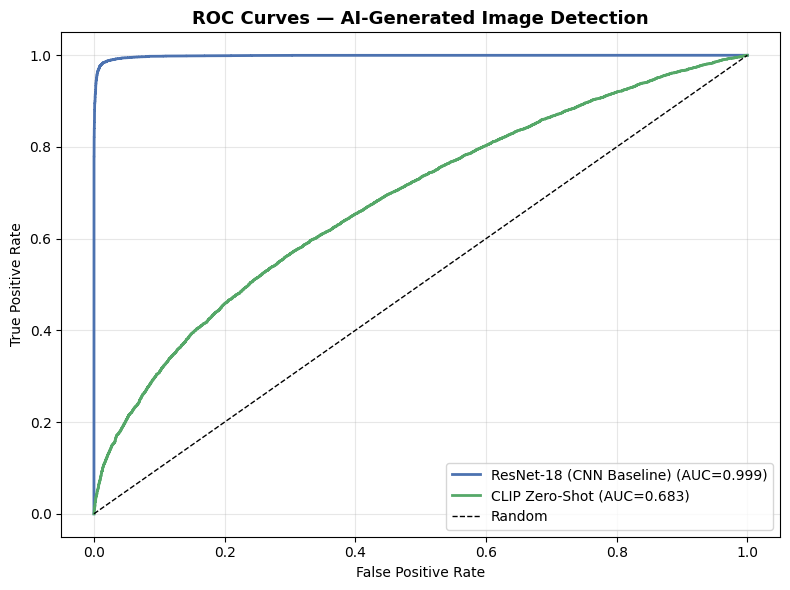

In [19]:
# ── ROC curves ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#4C72B0', '#55A868', '#C44E52']

for r, color in zip(all_results, colors):
    fpr, tpr, _ = roc_curve(r['labels'], r['probs'])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{r['model']} (AUC={r['auc']:.3f})")

ax.plot([0,1],[0,1],'k--', linewidth=1, label='Random')
ax.set_title('ROC Curves — AI-Generated Image Detection', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

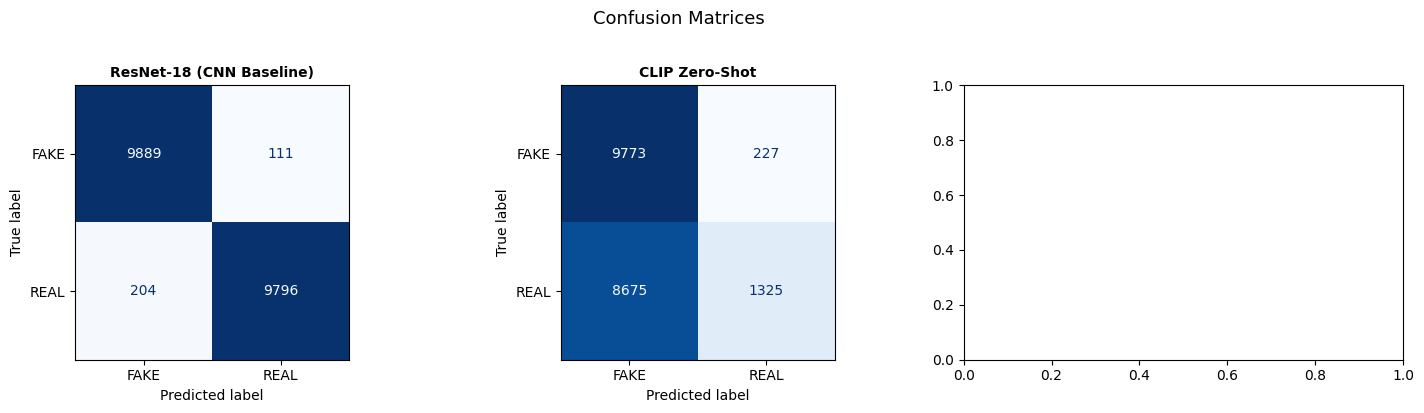

In [20]:
# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, r in zip(axes, all_results):
    cm = confusion_matrix(r['labels'], r['preds'])
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(r['model'], fontsize=10, fontweight='bold')
plt.suptitle('Confusion Matrices', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

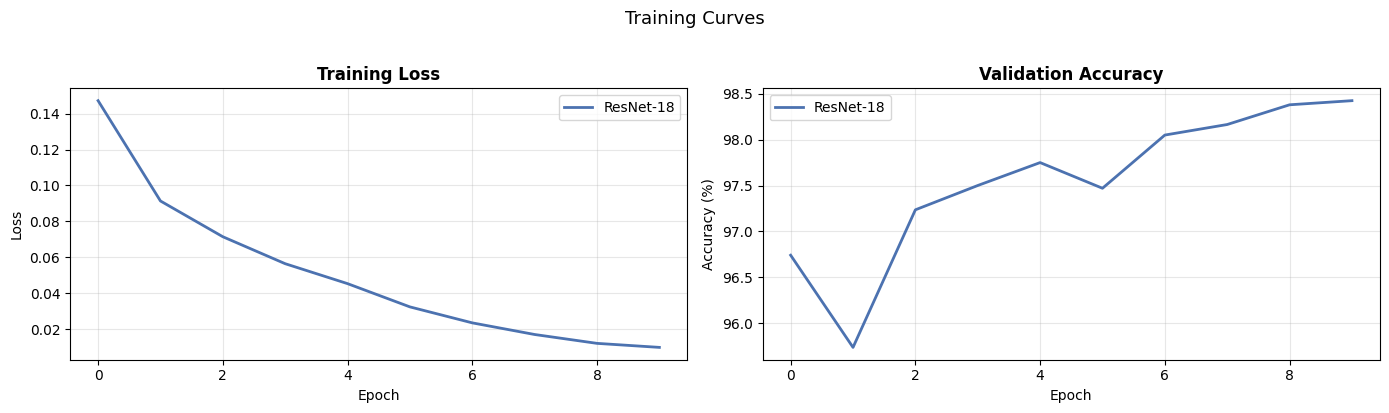

In [22]:
# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(resnet_losses, color='#4C72B0', linewidth=2, label='ResNet-18')
axes[0].set_title('Training Loss', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot([a*100 for a in resnet_accs], color='#4C72B0', linewidth=2, label='ResNet-18')
axes[1].set_title('Validation Accuracy', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Training Curves', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

Finding misclassified examples for ViT (best model)...


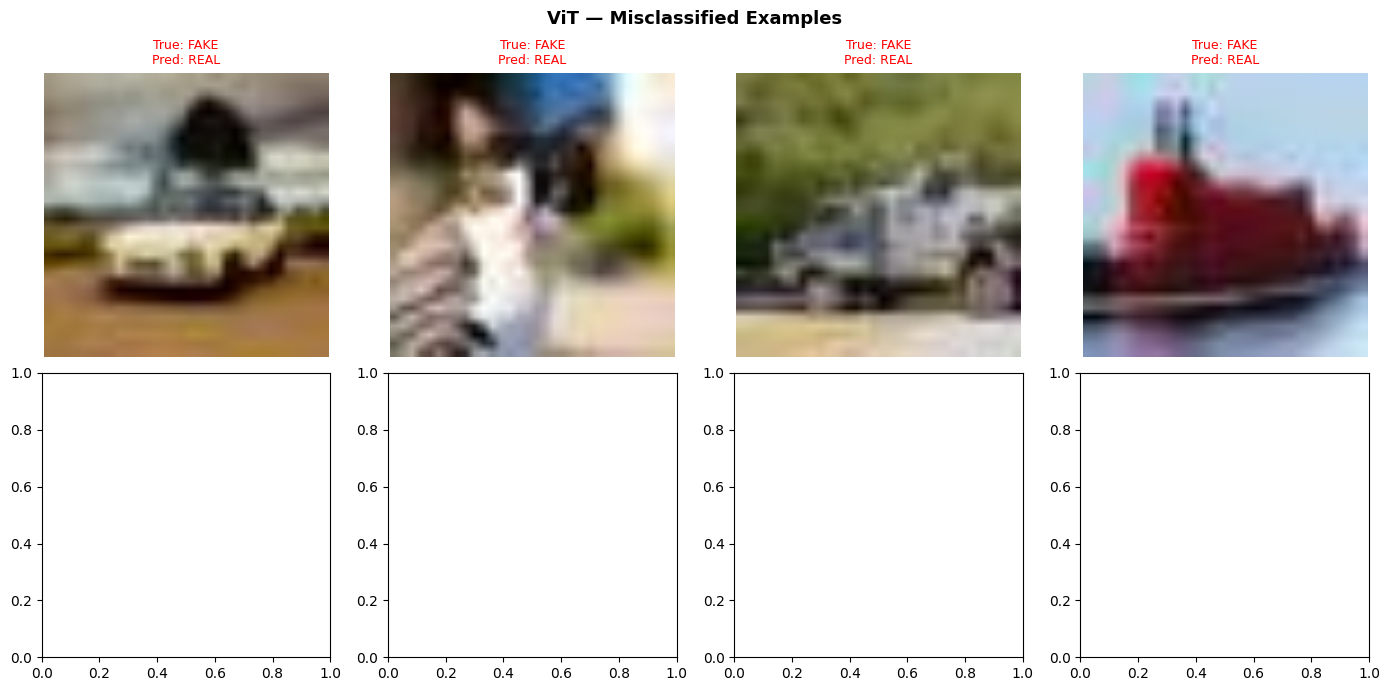

In [23]:
# ── Misclassified examples ────────────────────────────────────────────────────
print('Finding misclassified examples for ViT (best model)...')

vit_wrapper.eval()
misclassified = {'FAKE_as_REAL': [], 'REAL_as_FAKE': []}
test_no_aug = datasets.ImageFolder(TEST_DIR, transform=test_transform)

with torch.no_grad():
    for idx in range(min(2000, len(test_no_aug))):
        img_t, label = test_no_aug[idx]
        pred = vit_wrapper(img_t.unsqueeze(0).to(device)).argmax().item()
        if pred != label:
            key = 'FAKE_as_REAL' if label == 0 else 'REAL_as_FAKE'
            if len(misclassified[key]) < 4:
                misclassified[key].append((img_t, label, pred))
        if all(len(v) >= 4 for v in misclassified.values()):
            break

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

for row, (key, examples) in enumerate(misclassified.items()):
    for col, (img_t, true_l, pred_l) in enumerate(examples[:4]):
        img_show = (img_t * std + mean).clamp(0,1).permute(1,2,0).numpy()
        axes[row, col].imshow(img_show)
        axes[row, col].set_title(
            f'True: {CLASS_NAMES[true_l]}\nPred: {CLASS_NAMES[pred_l]}',
            fontsize=9, color='red')
        axes[row, col].axis('off')

plt.suptitle('ViT — Misclassified Examples', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('misclassified.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Save models ───────────────────────────────────────────────────────────────
os.makedirs('models', exist_ok=True)
torch.save(resnet.state_dict(),      'models/resnet18_cifake.pt')
torch.save(vit_wrapper.state_dict(), 'models/vit_cifake.pt')
print('Models saved ✅')

In [ ]:
# ── Download everything ───────────────────────────────────────────────────────
from google.colab import files
for fname in [
    'sample_images.png', 'pixel_stats.png', 'roc_curves.png',
    'confusion_matrices.png', 'training_curves.png', 'misclassified.png',
    'models/resnet18_cifake.pt', 'models/vit_cifake.pt'
]:
    try: files.download(fname)
    except: print(f'Skipping {fname}')
print('Done ')